# JURISIN 2026 Final Results


First, we upload the corpus easily with a button, store it in df and display the head.

In [1]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

df = None  # queda global

uploader = widgets.FileUpload(
    accept='.xlsx,.xls',
    multiple=False
)

def load_excel(change):
    global df
    uploaded_file = list(uploader.value.values())[0]
    df = pd.read_excel(uploaded_file['content'])
    print("Base cargada en df")
    display(df.head())

uploader.observe(load_excel, names='value')
display(uploader)


FileUpload(value=(), accept='.xlsx,.xls', description='Upload')

We store the columns names to avoid issues with ortography later

In [ ]:
data, cols = df.to_dict(orient="records"), df.columns.tolist()


## Description
We define the classes, create a bar chart with the distribution of articles by class and paint with beutiful colors inspired on Stromanthe.

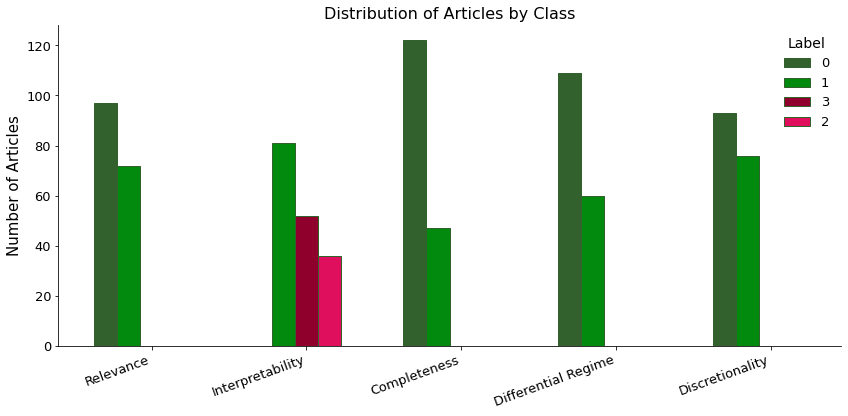

<Figure size 432x288 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

classes = [
    'Relevance',
    'Interpretability',
    'Completeness',
    'Differential Regime',
    'Discretionality'
]

palette = ['#32612D', '#028A0F', '#8F002C', '#E00F5E', '#7C9C7D', '#555555']

rows = []
for c in classes:
    counts = df[c].value_counts(dropna=False)
    for k, v in counts.items():
        rows.append({'Class': c, 'Label': str(k), 'Count': v})

plot_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 6))

labels = plot_df['Label'].unique()
x = np.arange(len(classes))
width = 0.15

for i, lab in enumerate(labels):
    vals = [
        plot_df[(plot_df['Class'] == c) & (plot_df['Label'] == lab)]['Count'].sum()
        for c in classes
    ]
    ax.bar(
        x + i * width,
        vals,
        width,
        label=lab,
        color=palette[i % len(palette)],
        edgecolor='#32612D'
    )

ax.set_xticks(x + width * len(labels) / 2)
ax.set_xticklabels(classes, rotation=20, ha='right')
ax.set_ylabel('Number of Articles')
ax.set_title('Distribution of Articles by Class')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Label', frameon=False)

plt.tight_layout()
plt.show()




## TD-IDF
We run the pipeline of TD IDF and store the results. 

In [10]:
import numpy as np
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import joblib

TEXT_COL = "Spanish text"
TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

df_ = df.copy()

# clean text
X_all = df_[TEXT_COL].astype("string").fillna("").str.strip()
text_mask = X_all.str.len() > 0
df_ = df_[text_mask].copy()
X_all = df_[TEXT_COL].astype("string").fillna("").str.strip().values

def _safe_name(s: str) -> str:
    s = str(s)
    s = re.sub(r"\s+", "_", s.strip())
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:120] if len(s) > 120 else s

all_summaries = []

for target in TARGETS:
    y_all = df_[target]
    valid = y_all.notna()
    X = X_all[valid.values]
    y = y_all[valid].astype(int).values

    # drop rare classes that break stratify
    vc = pd.Series(y).value_counts()
    keep = vc[vc >= 2].index
    keep_mask = pd.Series(y).isin(keep).values
    X, y = X[keep_mask], y[keep_mask]

    strat = y if len(np.unique(y)) > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=strat
    )

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            ngram_range=(1,2),
            min_df=2,
            max_features=50000
        )),
        ("clf", LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    labels = np.unique(np.concatenate([y_test, y_pred]))
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    safe_t = _safe_name(target)

    # save artifacts per target
    joblib.dump(pipe, f"model_tfidf_logreg__{safe_t}.joblib")
    pd.DataFrame(report).transpose().to_csv(f"report__{safe_t}.csv", index=True)
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(f"confmat__{safe_t}.csv", index=True)
    pd.DataFrame({"y_true": y_test, "y_pred": y_pred}).to_csv(f"preds__{safe_t}.csv", index=False)

    summary = {
        "target": target,
        "text_col": TEXT_COL,
        "n_rows_used": int(len(y)),
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "accuracy": float(acc),
        "precision_macro": float(prec_m),
        "recall_macro": float(rec_m),
        "f1_macro": float(f1_m),
        "classes": ",".join(map(str, sorted(pd.Series(y).unique().tolist())))
    }
    all_summaries.append(summary)

# global summary
summary_df = pd.DataFrame(all_summaries)
summary_df.to_csv("summary__all_targets.csv", index=False)

with open("results__all_targets.txt", "w", encoding="utf-8") as f:
    for r in all_summaries:
        f.write(
            f"{r['target']} | "
            f"n={r['n_rows_used']} "
            f"acc={r['accuracy']:.6f} "
            f"prec_macro={r['precision_macro']:.6f} "
            f"recall_macro={r['recall_macro']:.6f} "
            f"f1_macro={r['f1_macro']:.6f} "
            f"classes={r['classes']}\n"
        )

print("OK saved: summary__all_targets.csv, results__all_targets.txt + per-target model/report/confmat/preds")


OK saved: summary__all_targets.csv, results__all_targets.txt + per-target model/report/confmat/preds


## Legal BERT
We train LegalBert on the dataset and store the results

In [63]:
# pip install -U torch transformers scikit-learn pandas numpy joblib

import numpy as np
import pandas as pd
import re
import joblib
import torch

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

TEXT_COL = "Spanish text"
TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

# ✅ Legal-BERT
MODEL_NAME = "nlpaueb/legal-bert-base-uncased"

df_ = df.copy()

# ✅ stable ID for traceability
df_["id"] = df_["Law"].astype("string").fillna("").str.strip() + "__" + df_["Article"].astype("string").fillna("").str.strip()

# clean rows with text
X_series = df_[TEXT_COL].astype("string").fillna("").str.strip()
df_ = df_[X_series.str.len() > 0].copy()
texts_all = df_[TEXT_COL].astype("string").fillna("").str.strip().tolist()

def _safe_name(s: str) -> str:
    s = str(s)
    s = re.sub(r"\s+", "_", s.strip())
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:120] if len(s) > 120 else s

device = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
mdl = AutoModel.from_pretrained(MODEL_NAME).to(device)
mdl.eval()

@torch.no_grad()
def embed_texts(texts, batch_size=16, max_len=256):
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(batch, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
        out = mdl(**enc).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        embs.append(pooled.detach().cpu().numpy())
    return np.vstack(embs)

E_all = embed_texts(texts_all, batch_size=16, max_len=256)

summaries = []

for target in TARGETS:
    y0 = df_[target]
    valid = y0.notna().values
    E = E_all[valid]
    y = y0[valid].astype(int).values

    meta = df_.loc[valid, ["id", "Law", "Article"]].reset_index(drop=True)

    # drop rare classes
    vc = pd.Series(y).value_counts()
    keep = vc[vc >= 2].index
    keep_mask = pd.Series(y).isin(keep).values
    E, y = E[keep_mask], y[keep_mask]
    meta = meta.loc[keep_mask].reset_index(drop=True)

    strat = y if len(np.unique(y)) > 1 else None
    idx = np.arange(len(y))
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=strat)

    Xtr, Xte = E[tr_idx], E[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]
    meta_te = meta.loc[te_idx].copy()

    clf = LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced")
    clf.fit(Xtr, ytr)
    ypred = clf.predict(Xte)

    acc = accuracy_score(yte, ypred)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(yte, ypred, average="macro", zero_division=0)

    report = classification_report(yte, ypred, output_dict=True, zero_division=0)
    labels = np.unique(np.concatenate([yte, ypred]))
    cm = confusion_matrix(yte, ypred, labels=labels)

    st = _safe_name(target)

    # ✅ save model
    joblib.dump({"transformer": MODEL_NAME, "clf": clf}, f"model_legalbert_logreg__{st}.joblib")

    # ✅ save test preds WITH identifiers
    preds = meta_te.reset_index(drop=True)
    preds["target"] = target
    preds["y_true"] = yte
    preds["y_pred"] = ypred
    preds.to_csv(f"preds_legalbert__{st}.csv", index=False)

    # save reports
    pd.DataFrame(report).transpose().to_csv(f"report_legalbert__{st}.csv", index=True)
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(f"confmat_legalbert__{st}.csv", index=True)

    summaries.append({
        "target": target,
        "model": MODEL_NAME,
        "n_rows_used": int(len(y)),
        "n_train": int(len(ytr)),
        "n_test": int(len(yte)),
        "accuracy": float(acc),
        "precision_macro": float(p_m),
        "recall_macro": float(r_m),
        "f1_macro": float(f1_m),
        "classes": ",".join(map(str, sorted(pd.Series(y).unique().tolist())))
    })

pd.DataFrame(summaries).to_csv("summary_legalbert__all_targets.csv", index=False)

with open("results_legalbert__all_targets.txt", "w", encoding="utf-8") as f:
    f.write(f"MODEL={MODEL_NAME}\n")
    for r in summaries:
        f.write(
            f"{r['target']} | n={r['n_rows_used']} "
            f"acc={r['accuracy']:.6f} "
            f"prec_macro={r['precision_macro']:.6f} "
            f"recall_macro={r['recall_macro']:.6f} "
            f"f1_macro={r['f1_macro']:.6f} "
            f"classes={r['classes']}\n"
        )

print("OK saved: preds_legalbert__*.csv (with id/Law/Article), summary_legalbert__all_targets.csv, results_legalbert__all_targets.txt")


Some weights of the model checkpoint at nlpaueb/legal-bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


OK saved: preds_legalbert__*.csv (with id/Law/Article), summary_legalbert__all_targets.csv, results_legalbert__all_targets.txt


## MEL
We train MEL language and store the results

In [50]:
# pip install -U torch transformers scikit-learn pandas numpy joblib

import numpy as np
import pandas as pd
import re
import joblib
import torch

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

TEXT_COL = "Spanish text"
TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

MODEL_NAME = "IIC/MEL"

df_ = df.copy()

df_["id"] = (
    df_["Law"].astype("string").fillna("").str.strip()
    + "__"
    + df_["Article"].astype("string").fillna("").str.strip()
)

X_series = df_[TEXT_COL].astype("string").fillna("").str.strip()
df_ = df_[X_series.str.len() > 0].copy()
texts_all = df_[TEXT_COL].astype("string").fillna("").str.strip().tolist()

def _safe_name(s):
    s = re.sub(r"\s+", "_", str(s).strip())
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:120]

device = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
mdl = AutoModel.from_pretrained(MODEL_NAME).to(device)
mdl.eval()

@torch.no_grad()
def embed_texts(texts, batch_size=8, max_len=512):
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(
            batch,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        ).to(device)
        out = mdl(**enc).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        embs.append(pooled.cpu().numpy())
    return np.vstack(embs)

E_all = embed_texts(texts_all)

summaries = []

for target in TARGETS:
    y0 = df_[target]
    valid = y0.notna().values

    E = E_all[valid]
    y = y0[valid].astype(int).values
    meta = df_.loc[valid, ["id", "Law", "Article"]].reset_index(drop=True)

    vc = pd.Series(y).value_counts()
    keep = vc[vc >= 2].index
    keep_mask = pd.Series(y).isin(keep).values

    E, y = E[keep_mask], y[keep_mask]
    meta = meta.loc[keep_mask].reset_index(drop=True)

    strat = y if len(np.unique(y)) > 1 else None
    idx = np.arange(len(y))
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=strat)

    Xtr, Xte = E[tr_idx], E[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]

    meta_tr = meta.loc[tr_idx].copy()
    meta_te = meta.loc[te_idx].copy()

    clf = LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced")
    clf.fit(Xtr, ytr)

    ypred = clf.predict(Xte)

    # ✅ probabilities / scores
    classes = clf.classes_
    proba = clf.predict_proba(Xte)               # shape [n_test, n_classes]
    score = clf.decision_function(Xte)           # binary -> [n_test], multiclass -> [n_test, n_classes]

    # make score 2d consistently
    if score.ndim == 1:
        score = score.reshape(-1, 1)

    acc = accuracy_score(yte, ypred)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(yte, ypred, average="macro", zero_division=0)

    report = classification_report(yte, ypred, output_dict=True, zero_division=0)
    labels = np.unique(np.concatenate([yte, ypred]))
    cm = confusion_matrix(yte, ypred, labels=labels)

    st = _safe_name(target)

    joblib.dump({"model": MODEL_NAME, "clf": clf}, f"model_mel_logreg__{st}.joblib")
    pd.DataFrame(report).transpose().to_csv(f"report_mel__{st}.csv")
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(f"confmat_mel__{st}.csv")

    # ✅ save test preds WITH identifiers + probabilities + decision scores
    preds = meta_te.reset_index(drop=True)
    preds["target"] = target
    preds["y_true"] = yte
    preds["y_pred"] = ypred

    # add proba columns per class
    for j, c in enumerate(classes):
        preds[f"proba_class_{c}"] = proba[:, j]

    # add score columns (decision function) per class (or single score)
    if len(classes) == 2:
        preds["decision_score"] = score[:, 0]
    else:
        for j, c in enumerate(classes):
            preds[f"decision_score_class_{c}"] = score[:, j]

    preds.to_csv(f"preds_mel__{st}.csv", index=False)

    meta_tr.assign(split="train", target=target).to_csv(f"split_ids_mel__{st}__train.csv", index=False)
    meta_te.assign(split="test",  target=target).to_csv(f"split_ids_mel__{st}__test.csv",  index=False)

    summaries.append({
        "target": target,
        "model": MODEL_NAME,
        "n": int(len(y)),
        "accuracy": float(acc),
        "precision_macro": float(p_m),
        "recall_macro": float(r_m),
        "f1_macro": float(f1_m),
        "classes": ",".join(map(str, sorted(pd.Series(y).unique())))
    })

pd.DataFrame(summaries).to_csv("summary_mel__all_targets.csv", index=False)

with open("results_mel__all_targets.txt", "w", encoding="utf-8") as f:
    f.write(f"MODEL={MODEL_NAME}\n")
    for r in summaries:
        f.write(
            f"{r['target']} | "
            f"n={r['n']} "
            f"acc={r['accuracy']:.6f} "
            f"prec_macro={r['precision_macro']:.6f} "
            f"recall_macro={r['recall_macro']:.6f} "
            f"f1_macro={r['f1_macro']:.6f} "
            f"classes={r['classes']}\n"
        )

np.save("mel_embeddings.npy", E_all)

print("OK saved: preds_mel__*.csv (with ids + proba), split_ids_mel__*__train/test.csv, mel_embeddings.npy, summary_mel__all_targets.csv")


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: ede13042-01bb-4481-b89c-df5660d0db75)')' thrown while requesting HEAD https://huggingface.co/IIC/MEL/resolve/main/config.json


OK saved: preds_mel__*.csv (with ids + proba), split_ids_mel__*__train/test.csv, mel_embeddings.npy, summary_mel__all_targets.csv


we install umap

In [17]:
%pip install umap-learn


It goes wrong because my python is old and fix it

In [22]:
# FIX (Python <3.8): patch importlib.metadata so umap can import
import sys
import importlib_metadata
sys.modules["importlib.metadata"] = importlib_metadata

import umap.umap_ as umap


## Embeddings
Here, we obtain the embbeding of MEL and project with UMAP. We store the df with the coordenates.

In [114]:
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel

import importlib_metadata  # <-- add
import umap.umap_ as umap  # <-- replace

TEXT_COL = "Spanish text"
MODEL_NAME = "IIC/MEL"

df_ = df.copy()
texts = df_[TEXT_COL].astype("string").fillna("").str.strip()
mask = texts.str.len() > 0
df_ = df_[mask].copy()
texts = df_[TEXT_COL].astype("string").fillna("").str.strip().tolist()

device = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
mdl = AutoModel.from_pretrained(MODEL_NAME).to(device)
mdl.eval()

@torch.no_grad()
def embed_texts(texts, batch_size=8, max_len=512):
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(batch, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
        out = mdl(**enc).last_hidden_state
        attn = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (out * attn).sum(1) / attn.sum(1).clamp(min=1e-9)
        embs.append(pooled.cpu().numpy())
    return np.vstack(embs)

E = embed_texts(texts)

Z = umap.UMAP().fit_transform(E)

df_["umap_x"] = Z[:, 0]
df_["umap_y"] = Z[:, 1]

df_.to_csv("mel_umap_2d.csv", index=False)
np.save("mel_embeddings.npy", E)

print("OK saved: mel_umap_2d.csv, mel_embeddings.npy")


KeyboardInterrupt: 

We create the scatter plot of the MEL-UMAP for every category

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

palette = ['#32612D', '#028A0F', '#8F002C', '#E00F5E', '#7C9C7D', '#555555']
TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

assert "umap_x" in df_.columns and "umap_y" in df_.columns, "Faltan columnas umap_x / umap_y en df_"

def masks_from_rule(vals):
    vals = pd.Series(vals)
    uniq = set(vals.dropna().unique().tolist())
    if uniq.issubset({0, 1}):
        m_col = vals == 1
        m_grey = vals == 0
    else:
        m_col = vals.isin([2, 3])
        m_grey = vals.isin([0, 1])
    return m_col.to_numpy(), m_grey.to_numpy()

for i, col in enumerate(TARGETS):
    d = df_[["umap_x", "umap_y", col]].dropna().copy()

    x = d["umap_x"].to_numpy()
    y2 = d["umap_y"].to_numpy()
    v = d[col].to_numpy()

    m_col, m_grey = masks_from_rule(v)
    c = palette[i % len(palette)]
    grey = palette[-1]

    plt.figure(figsize=(7,5))
    plt.scatter(x[m_grey], y2[m_grey], c=grey, alpha=0.15, s=10, linewidths=0)
    plt.scatter(x[m_col],  y2[m_col],  c=c,    alpha=0.75, s=14, linewidths=0)

    plt.title(f"UMAP (MEL) - {col}")
    plt.xlabel("umap_x")
    plt.ylabel("umap_y")

    uniq = set(pd.Series(v).dropna().unique().tolist())
    if uniq.issubset({0, 1}):
        grey_lbl, col_lbl = "0", "1"
    else:
        grey_lbl, col_lbl = "0/1", "2/3"

    leg = [
        Line2D([0],[0], marker="o", color="none", label=f"Gris ({grey_lbl})",
               markerfacecolor=grey, markersize=8, alpha=0.35),
        Line2D([0],[0], marker="o", color="none", label=f"Color ({col_lbl})",
               markerfacecolor=c, markersize=8, alpha=0.85),
    ]
    plt.legend(handles=leg, loc="best", frameon=True)

    plt.tight_layout()
    plt.savefig(f"scatter_mel_umap__{col.replace(' ','_')}.png", dpi=200)
    plt.close()

print("OK saved: scatter_mel_umap__*.png")



OK saved: scatter_mel_umap__*.png


we store the data of the chart in case we want to edit outside.

In [27]:
import pandas as pd
import numpy as np

TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

def masks_from_rule(vals):
    vals = pd.Series(vals)
    uniq = set(vals.dropna().unique().tolist())
    if uniq.issubset({0, 1}):
        m_col = vals == 1
        m_grey = vals == 0
        rule = "binary: gray=0, color=1"
        grp = np.where(m_col.to_numpy(), "color(1)", np.where(m_grey.to_numpy(), "gray(0)", "other"))
    else:
        m_col = vals.isin([2, 3])
        m_grey = vals.isin([0, 1])
        rule = "multi: gray=0/1, color=2/3"
        grp = np.where(m_col.to_numpy(), "color(2/3)", np.where(m_grey.to_numpy(), "gray(0/1)", "other"))
    return m_col.to_numpy(), m_grey.to_numpy(), rule, grp

for col in TARGETS:
    d = df_[["Law", "Article", "umap_x", "umap_y", col]].dropna().copy()
    v = d[col].to_numpy()

    m_col, m_grey, rule, grp = masks_from_rule(v)

    out = pd.DataFrame({
        "Law": d["Law"].astype("string").values,
        "Article": d["Article"].values,
        "target": col,
        "target_value": d[col].values,
        "color_group": grp,
        "umap_x": d["umap_x"].values,
        "umap_y": d["umap_y"].values,
    })

    out.to_csv(f"scatter_data__{col.replace(' ','_')}.csv", index=False)

print("OK saved: scatter_data__*.csv")


OK saved: scatter_data__*.csv


We create the kde chart of every category

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

palette = ['#32612D', '#028A0F', '#8F002C', '#E00F5E', '#7C9C7D', '#555555']
TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

assert "umap_x" in df_.columns and "umap_y" in df_.columns, "Faltan columnas umap_x / umap_y en df_"

# knobs
LEVELS = 30          # more contour levels
GRIDSIZE = 300       # denser evaluation grid
ALPHA = 0.30         # overlap visibility
BW_ADJUST = 0.7      # <1 sharper, >1 smoother
THRESH = 0.02        # hide tiny density

def masks_from_rule(vals):
    vals = pd.Series(vals)
    uniq = set(vals.dropna().unique().tolist())
    if uniq.issubset({0, 1}):
        m_col = vals == 1
        m_grey = vals == 0
        grey_lbl, col_lbl = "0", "1"
    else:
        m_col = vals.isin([2, 3])
        m_grey = vals.isin([0, 1])
        grey_lbl, col_lbl = "0/1", "2/3"
    return m_col.to_numpy(), m_grey.to_numpy(), grey_lbl, col_lbl

for i, col in enumerate(TARGETS):
    d = df_[["umap_x", "umap_y", col]].dropna().copy()

    x = d["umap_x"].to_numpy()
    y = d["umap_y"].to_numpy()
    v = d[col].to_numpy()

    m_col, m_grey, grey_lbl, col_lbl = masks_from_rule(v)

    c = palette[i % len(palette)]
    grey = palette[-1]

    plt.figure(figsize=(7,5))

    # grey KDE first
    if m_grey.sum() > 5:
        sns.kdeplot(
            x=x[m_grey], y=y[m_grey],
            fill=True,
            color=grey,
            alpha=ALPHA,
            levels=LEVELS,
            thresh=THRESH,
            gridsize=GRIDSIZE,
            bw_adjust=BW_ADJUST
        )

    # colored KDE second
    if m_col.sum() > 5:
        sns.kdeplot(
            x=x[m_col], y=y[m_col],
            fill=True,
            color=c,
            alpha=ALPHA,
            levels=LEVELS,
            thresh=THRESH,
            gridsize=GRIDSIZE,
            bw_adjust=BW_ADJUST
        )

    plt.title(f"UMAP KDE (MEL) - {col}")
    plt.xlabel("umap_x")
    plt.ylabel("umap_y")

    leg = [
        Line2D([0],[0], color=grey, lw=6, alpha=ALPHA, label=f"Gris ({grey_lbl})"),
        Line2D([0],[0], color=c,    lw=6, alpha=ALPHA, label=f"Color ({col_lbl})"),
    ]
    plt.legend(handles=leg, loc="best", frameon=True)

    plt.tight_layout()
    plt.savefig(f"kde_mel_umap__{col.replace(' ','_')}.png", dpi=200)
    plt.close()

print("OK saved: kde_mel_umap__*.png")



OK saved: kde_mel_umap__*.png


we store the data of the plots

In [29]:
import pandas as pd
import numpy as np

TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

def masks_from_rule(vals):
    vals = pd.Series(vals)
    uniq = set(vals.dropna().unique().tolist())
    if uniq.issubset({0, 1}):
        m_col = vals == 1
        m_grey = vals == 0
        rule = "binary: gray=0, color=1"
        grp = np.where(m_col.to_numpy(), "color(1)", "gray(0)")
    else:
        m_col = vals.isin([2, 3])
        m_grey = vals.isin([0, 1])
        rule = "multi: gray=0/1, color=2/3"
        grp = np.where(m_col.to_numpy(), "color(2/3)", "gray(0/1)")
    return grp, rule

for col in TARGETS:
    d = df_[["Law", "Article", "umap_x", "umap_y", col]].dropna().copy()
    grp, rule = masks_from_rule(d[col])

    out = pd.DataFrame({
        "Law": d["Law"].astype("string").values,
        "Article": d["Article"].values,
        "target": col,
        "target_value": d[col].values,
        "group": grp,
        "umap_x": d["umap_x"].values,
        "umap_y": d["umap_y"].values,
        "rule": rule
    })

    out.to_csv(f"kde_data__{col.replace(' ','_')}.csv", index=False)

print("OK saved: kde_data__*.csv")


OK saved: kde_data__*.csv


We create a kde for the gray area vs non gray area articles

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

palette = ['#32612D', '#028A0F', '#8F002C', '#E00F5E', '#7C9C7D', '#555555']

assert "umap_x" in df_.columns and "umap_y" in df_.columns, "Faltan columnas umap_x / umap_y en df_"

BIN_COLS = ["Relevance", "Completeness", "Differential Regime", "Discretionality"]
INTERP_COL = "Interpretability"

d = df_[["umap_x","umap_y", INTERP_COL] + BIN_COLS].dropna().copy()

x = d["umap_x"].to_numpy()
y = d["umap_y"].to_numpy()

all_bin_zero = (d[BIN_COLS] == 0).all(axis=1).to_numpy()
interp_is_1  = (d[INTERP_COL] == 1).to_numpy()

m_grey = all_bin_zero | interp_is_1
m_col  = ~m_grey

grey = palette[-1]
col  = palette[0]

plt.figure(figsize=(7,5))
plt.scatter(x[m_grey], y[m_grey], c=grey, alpha=0.15, s=10, linewidths=0)
plt.scatter(x[m_col],  y[m_col],  c=col,  alpha=0.75, s=14, linewidths=0)

plt.title("UMAP (MEL) - Gray rule (all binary=0 OR Interpretability=1)")
plt.xlabel("umap_x")
plt.ylabel("umap_y")

leg = [
    Line2D([0],[0], marker="o", color="none", label="Gris: all binary=0 OR Interpretability=1",
           markerfacecolor=grey, markersize=8, alpha=0.35),
    Line2D([0],[0], marker="o", color="none", label="Color: otherwise",
           markerfacecolor=col, markersize=8, alpha=0.85),
]
plt.legend(handles=leg, loc="best", frameon=True)

plt.tight_layout()
plt.savefig("scatter_mel_umap__gray_rule_allbin0_or_interp1.png", dpi=200)
plt.close()

print("OK saved: scatter_mel_umap__gray_rule_allbin0_or_interp1.png")


OK saved: scatter_mel_umap__gray_rule_allbin0_or_interp1.png


We store the plot data

In [32]:
import pandas as pd
import numpy as np

BIN_COLS = ["Relevance", "Completeness", "Differential Regime", "Discretionality"]
INTERP_COL = "Interpretability"

d = df_[["Law", "Article", "umap_x", "umap_y", INTERP_COL] + BIN_COLS].dropna().copy()

all_bin_zero = (d[BIN_COLS] == 0).all(axis=1)
interp_is_1  = (d[INTERP_COL] == 1)

d["color_group"] = np.where(all_bin_zero | interp_is_1, "grey", "color")

out = d[[
    "Law", "Article",
    "umap_x", "umap_y",
    INTERP_COL, *BIN_COLS,
    "color_group"
]]

out.to_csv("scatter_data__gray_rule_allbin0_or_interp1.csv", index=False)

print("OK saved: scatter_data__gray_rule_allbin0_or_interp1.csv")


OK saved: scatter_data__gray_rule_allbin0_or_interp1.csv


We create the risk score and compare articles with more or less than 4.5 in complexity score and store

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# --- params ---
CATS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]
THRESH = 4.5
LEVELS = 30
GRIDSIZE = 300
ALPHA = 0.30
BW_ADJUST = 0.7

# --- Risk Score ---
df_["Risk Score"] = df_[CATS].sum(axis=1)

# --- KDE UMAP by Risk Score ---
assert "umap_x" in df_.columns and "umap_y" in df_.columns

d = df_[["umap_x", "umap_y", "Risk Score"]].dropna().copy()

x = d["umap_x"].to_numpy()
y = d["umap_y"].to_numpy()
risk = d["Risk Score"].to_numpy()

m_col = risk > THRESH
m_grey = ~m_col

grey = "#555555"
col = "#8F002C"

plt.figure(figsize=(7,5))

if m_grey.sum() > 5:
    sns.kdeplot(
        x=x[m_grey], y=y[m_grey],
        fill=True, color=grey, alpha=ALPHA,
        levels=LEVELS, gridsize=GRIDSIZE,
        bw_adjust=BW_ADJUST, thresh=0.02
    )

if m_col.sum() > 5:
    sns.kdeplot(
        x=x[m_col], y=y[m_col],
        fill=True, color=col, alpha=ALPHA,
        levels=LEVELS, gridsize=GRIDSIZE,
        bw_adjust=BW_ADJUST, thresh=0.02
    )

plt.title("UMAP KDE (MEL) — Risk Score > 4.5")
plt.xlabel("umap_x")
plt.ylabel("umap_y")

leg = [
    Line2D([0],[0], color=grey, lw=6, alpha=ALPHA, label="Risk Score ≤ 4.5"),
    Line2D([0],[0], color=col,  lw=6, alpha=ALPHA, label="Risk Score > 4.5"),
]
plt.legend(handles=leg, loc="best", frameon=True)

plt.tight_layout()
plt.savefig("kde_mel_umap__risk_score_gt_4_5.png", dpi=200)
plt.close()

# --- save data ---
df_[["umap_x","umap_y","Risk Score"] + CATS].to_csv("kde_data__risk_score.csv", index=False)

print("OK saved: kde_mel_umap__risk_score_gt_4_5.png, kde_data__risk_score.csv")


OK saved: kde_mel_umap__risk_score_gt_4_5.png, kde_data__risk_score.csv


## Sensitivity Analysis
Here we create a function to create synonims and to change phrase order but conserving the semantic of the text.

In [71]:
import re
import random
import unicodedata

# minimal ES stopwords (extend if needed)
ES_STOPWORDS = {
    "a","al","algo","algunas","algunos","ante","antes","como","con","contra","cual","cuales","cuando","de","del",
    "desde","donde","dos","el","ella","ellas","ellos","en","entre","era","erais","eran","eras","eres","es","esa",
    "esas","ese","eso","esos","esta","estaba","estabais","estaban","estabas","estad","estada","estadas","estado",
    "estados","estamos","estando","estar","estaremos","estará","estarán","estarás","estaré","estaréis","estaría",
    "estaríais","estaríamos","estarían","estarías","estas","este","estemos","esto","estos","estoy","estuve",
    "estuviera","estuvierais","estuvieran","estuvieras","estuvieron","estuviese","estuvieseis","estuviesen",
    "estuvieses","estuvimos","estuviste","estuvisteis","estuvo","fue","fuera","fuerais","fueran","fueras","fueron",
    "fuese","fueseis","fuesen","fueses","fui","fuimos","fuiste","fuisteis","ha","había","habíais","habían","habías",
    "habéis","habemos","haber","habrá","habrán","habrás","habré","habréis","habría","habríais","habríamos","habrían",
    "habrías","han","has","hasta","hay","haya","hayáis","hayan","hayas","he","hemos","hube","hubiera","hubierais",
    "hubieran","hubieras","hubieron","hubiese","hubieseis","hubiesen","hubieses","hubimos","hubiste","hubisteis",
    "hubo","la","las","le","les","lo","los","mas","me","mi","mis","mucho","muy","más","mí","mío","mía","mías","míos",
    "nada","ni","no","nos","nosotras","nosotros","nuestra","nuestras","nuestro","nuestros","o","os","otra","otras",
    "otro","otros","para","pero","poco","por","porque","que","quien","quienes","qué","se","sea","seáis","sean","seas",
    "ser","seremos","será","serán","serás","seré","seréis","sería","seríais","seríamos","serían","serías","si","sido",
    "siendo","sin","sobre","sois","somos","son","soy","su","sus","suya","suyas","suyo","suyos","sí","también","tanto",
    "te","tened","tenemos","tenga","tengamos","tengan","tengas","tengo","tenido","teniendo","tener","tendrá","tendrán",
    "tendrás","tendré","tendréis","tendría","tendríais","tendríamos","tendrían","tendrías","tenía","teníais","teníamos",
    "tenían","tenías","ti","tiene","tienen","tienes","todo","todos","tu","tus","tuve","tuviera","tuvierais","tuvieran",
    "tuvieras","tuvieron","tuviese","tuvieseis","tuviesen","tuvieses","tuvimos","tuviste","tuvisteis","tuvo","tuya",
    "tuyas","tuyo","tuyos","un","una","uno","unos","usas","usted","ustedes","y","ya","yo","él","ella","ellos","ellas"
}

_SENT_SPLIT_RE = re.compile(r'([^.!?;:]+[.!?;:]+|[^.!?;:]+$)', flags=re.UNICODE)
_WORD_RE = re.compile(r"\b[\wáéíóúüñÁÉÍÓÚÜÑ]+\b", flags=re.UNICODE)

def perturb_phrase_reorder(text: str) -> str:
    if not text or not text.strip():
        return text
    parts = [p.strip() for p in _SENT_SPLIT_RE.findall(text.strip()) if p.strip()]
    if len(parts) <= 1:
        return text
    random.shuffle(parts)
    out = " ".join(parts)
    out = re.sub(r"\s+", " ", out).strip()
    return out

def _strip_accents(s: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

def _preserve_case(src: str, repl: str) -> str:
    if src.isupper():
        return repl.upper()
    if src[:1].isupper():
        return repl[:1].upper() + repl[1:]
    return repl

def perturb_synonym_replace(text: str, pct: float = 0.1) -> str:
    if not text or not text.strip():
        return text
    pct = float(pct)
    if pct <= 0:
        return text

    try:
        from nltk.corpus import wordnet as wn
        wn.ensure_loaded()
        HAVE_WN = True
    except Exception:
        HAVE_WN = False

    tokens = list(_WORD_RE.finditer(text))
    if not tokens:
        return text

    # candidates: non-stopwords
    cand_idx = []
    for i, m in enumerate(tokens):
        w = m.group(0)
        wl = _strip_accents(w.lower())
        if wl in ES_STOPWORDS:
            continue
        # keep words with letters only
        if not re.search(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]", w):
            continue
        cand_idx.append(i)

    if not cand_idx:
        return text

    k = max(1, int(round(len(cand_idx) * pct)))
    chosen = set(random.sample(cand_idx, k=min(k, len(cand_idx))))

    # build replacements
    repl_map = {}
    for i in chosen:
        w = tokens[i].group(0)
        wl = w.lower()

        syns = []
        if HAVE_WN:
            for syn in wn.synsets(wl, lang="spa"):
                for lem in syn.lemma_names("spa"):
                    lem = lem.replace("_", " ").strip()
                    if not lem:
                        continue
                    if lem.lower() == wl:
                        continue
                    if " " in lem:
                        continue
                    syns.append(lem)

        syns = list({s for s in syns if s})
        if not syns:
            continue

        new_w = _preserve_case(w, random.choice(syns))
        repl_map[(tokens[i].start(), tokens[i].end())] = new_w

    if not repl_map:
        return text

    # apply replacements from end to start
    out = text
    for (a, b) in sorted(repl_map.keys(), reverse=True):
        out = out[:a] + repl_map[(a, b)] + out[b:]
    return out


We add two columns transforming the spanish text with synonims and phrase order and store the database

In [72]:
TEXT_COL = "Spanish text"

df_["Spanish text__phrase_reorder"] = (
    df_[TEXT_COL].astype("string").fillna("").apply(perturb_phrase_reorder)
)

df_["Spanish text__syn_replace_10pct"] = (
    df_[TEXT_COL].astype("string").fillna("")
        .apply(lambda t: perturb_synonym_replace(t, pct=0.1))
)

df_.to_csv("base_with_risk_score_and_perturbations.csv", index=False)

print("OK saved: base_with_risk_score_and_perturbations.csv")


OK saved: base_with_risk_score_and_perturbations.csv


we make the embeddings of the two new configurations and store them

In [73]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

# -------- CONFIG --------
TEXT_SYN  = "Spanish text__syn_replace_10pct"
TEXT_PHRA = "Spanish text__phrase_reorder"
MODEL_NAME = "IIC/MEL"

# -------- LOAD TRANSFORMER (embeddings only) --------
device = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
mdl = AutoModel.from_pretrained(MODEL_NAME).to(device)
mdl.eval()

@torch.no_grad()
def embed_texts(texts, batch_size=8, max_len=512):
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(
            batch,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        ).to(device)
        out = mdl(**enc).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        embs.append(pooled.cpu().numpy())
    return np.vstack(embs)

# -------- PREP DATA --------
texts_syn  = df_[TEXT_SYN].astype("string").fillna("").tolist()
texts_phra = df_[TEXT_PHRA].astype("string").fillna("").tolist()

# -------- EMBEDDINGS --------
E_syn  = embed_texts(texts_syn)
E_phra = embed_texts(texts_phra)

# -------- SAVE --------
np.save("mel_embeddings__syn_replace_10pct.npy", E_syn)
np.save("mel_embeddings__phrase_reorder.npy", E_phra)

print("OK saved: mel_embeddings__syn_replace_10pct.npy, mel_embeddings__phrase_reorder.npy")


OK saved: mel_embeddings__syn_replace_10pct.npy, mel_embeddings__phrase_reorder.npy


We now make classification on the test sample 

In [76]:
import numpy as np
import pandas as pd
import joblib

TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

# embeddings already computed/saved (full df_ order)
E_syn  = np.load("mel_embeddings__syn_replace_10pct.npy")
E_phra = np.load("mel_embeddings__phrase_reorder.npy")

# ensure df_ has same id used in splits
if "id" not in df_.columns:
    df_["id"] = (
        df_["Law"].astype("string").fillna("").str.strip()
        + "__"
        + df_["Article"].astype("string").fillna("").str.strip()
    )

# map id -> row index (df_ order must match embeddings order)
id_to_idx = pd.Series(np.arange(len(df_)), index=df_["id"]).to_dict()

for target in TARGETS:
    st = target.replace(" ", "_")

    test_ids = pd.read_csv(f"split_ids_mel__{st}__test.csv")
    idx = test_ids["id"].map(id_to_idx).dropna().astype(int).to_numpy()

    pack = joblib.load(f"model_mel_logreg__{st}.joblib")
    clf = pack["clf"]

    p_syn  = clf.predict(E_syn[idx])
    p_phra = clf.predict(E_phra[idx])

    out = test_ids.copy()
    out["target"] = target
    out["pred_synonyms"] = p_syn.astype(int)
    out["pred_phrases"]  = p_phra.astype(int)

    out.to_csv(f"preds_mel__{st}__test_syn_phr.csv", index=False)

print("OK saved: preds_mel__*__test_syn_phr.csv")



OK saved: preds_mel__*__test_syn_phr.csv


we now calculate precision macro, recall macro, f1 macro, change in probability, flip rate and performance drop

In [77]:
robustness = (
    preds_df
    .groupby("target")
    .apply(lambda g: pd.Series({
        "precision_macro": precision_recall_fscore_support(g.y_true, g.y_pred, average="macro", zero_division=0)[0],
        "recall_macro":    precision_recall_fscore_support(g.y_true, g.y_pred, average="macro", zero_division=0)[1],
        "f1_macro":        precision_recall_fscore_support(g.y_true, g.y_pred, average="macro", zero_division=0)[2],
        "flip_rate":       (g.changed_synonyms | g.changed_phrases).mean(),
        "prob_change":     (g.filter(like="proba_").diff(axis=1).abs().mean(axis=1)).mean(),
        "performance_drop": (
            precision_recall_fscore_support(g.y_true, g.pred_original, average="macro", zero_division=0)[2]
            - precision_recall_fscore_support(g.y_true, g.pred_synonyms, average="macro", zero_division=0)[2]
        )
    }))
    .reset_index()
)


NameError: name 'preds_df' is not defined

## LLM classification
We had an LLM do the classification task given our definitions. We include here columns with the classification of the LLM. 

A colleague did the job. We upload and store the db.

In [87]:
df_llm = pd.read_excel("gemini_final_comparison_updated.xlsx")
df_llm

,ID,Text,Expert_Relevance,AI_Relevance,Expert_Interpretability,AI_Interpretability,Expert_Completeness,AI_Completeness,Expert_Differential_Regime,AI_Differential_Regime,Expert_Discretionality,AI_Discretionality
0,Ley 105 de 1958_22,Todas las mercancías o materias primas que ent...,1,1,3,1,1,0,1,1,1,0
1,Ley 105 de 1958_27,Cuando se introduzcan al país artículos elabor...,1,1,3,2,1,0,1,1,1,1
2,Ley 47 de 1981_28,De la reexpedición de mercancías. La reexpedic...,1,1,3,1,1,1,1,1,1,1
3,Ley 47 de 1981_37,De los gravámenes aplicables a insumos y mater...,1,1,3,1,1,1,1,1,1,0
4,Ley 109 de 1985_34,DE LAS ZONAS FRANCAS DE CARACTER TRANSITORIO. ...,1,1,3,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
164,Ley 109 de 1985_31,DE LA CONTABILIDAD DE LAS ZONAS FRANCAS. Las z...,0,1,1,1,0,1,0,1,0,0
165,Ley 109 de 1985_40,DEL CONTROL DE LA GESTION FISCAL. La vigilanci...,0,0,1,1,0,0,0,0,0,0
166,Ley 109 de 1985_41,DE LA VIGENCIA. Esta Ley rige desde su publica...,0,0,1,1,0,0,0,0,0,0
167,Ley 1004 de 2005_6,Modifícase el numeral primero (1º) del artícul...,0,1,1,1,0,0,0,0,0,0


In [99]:
import pandas as pd
import plotly.graph_objects as go

EXPERT_COL = "expert_relevance"
AI_COL = "AI_relevance"

def to_bool(x):
    if pd.isna(x):
        return pd.NA
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, float)):
        if x == 1:
            return True
        if x == 0:
            return False
        return pd.NA
    s = str(x).strip().lower()
    if s in {"true", "t", "yes", "y", "si", "sí", "1"}:
        return True
    if s in {"false", "f", "no", "n", "0"}:
        return False
    return pd.NA

# ---- Prepare data ----
d = df_llm[[EXPERT_COL, AI_COL]].copy()
d[EXPERT_COL] = d[EXPERT_COL].apply(to_bool)
d[AI_COL] = d[AI_COL].apply(to_bool)
d = d.dropna(subset=[EXPERT_COL, AI_COL])

# ---- Crosstab ----
ct = pd.crosstab(d[EXPERT_COL], d[AI_COL])

# Ensure all combinations exist
for r in [False, True]:
    if r not in ct.index:
        ct.loc[r] = 0
for c in [False, True]:
    if c not in ct.columns:
        ct[c] = 0
ct = ct.sort_index().reindex(sorted(ct.columns), axis=1)

# ---- Sankey nodes ----
labels = [
    "Expert: False",  # 0
    "Expert: True",   # 1
    "AI: False",      # 2
    "AI: True",       # 3
]

sources = [0, 0, 1, 1]
targets = [2, 3, 2, 3]
values = [
    int(ct.loc[False, False]),
    int(ct.loc[False, True]),
    int(ct.loc[True,  False]),
    int(ct.loc[True,  True]),
]

# ---- Plot ----
fig = go.Figure(
    go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=20,
            line=dict(width=0.5),
            label=labels,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
        ),
    )
)

fig.update_layout(
    title="Sankey — Expert Relevance → AI Relevance",
    font_size=14,
)

fig.show()

# Optional: save
fig.write_html("sankey_relevance.html", include_plotlyjs="cdn")

print("Expert × AI relevance counts:")
print(ct)


KeyError: "None of [Index(['expert_relevance', 'AI_relevance'], dtype='object')] are in the [columns]"

## Complexity analysis

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- thresholds (central values) ---
cx = df_["complexity index"].median()
ry = df_["Risk Score"].median()

# --- data ---
d = df_[["complexity index", "Risk Score"]].dropna().copy()
x = d["complexity index"].to_numpy()
y = d["Risk Score"].to_numpy()

# --- plot ---
plt.figure(figsize=(7,6))

plt.scatter(x, y, c="#555555", alpha=0.5, s=18, linewidths=0)

# quadrant lines
plt.axvline(cx, color="black", linestyle="--", linewidth=1)
plt.axhline(ry, color="black", linestyle="--", linewidth=1)

# labels
plt.xlabel("Complexity Index")
plt.ylabel("Risk Score")
plt.title("Quadrants: Legal Complexity vs Risk Score")

# quadrant annotations
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

plt.text((xmin+cx)/2, (ymin+ry)/2, "Low Complexity\nLow Risk", ha="center", va="center")
plt.text((cx+xmax)/2, (ymin+ry)/2, "High Complexity\nLow Risk", ha="center", va="center")
plt.text((xmin+cx)/2, (ry+ymax)/2, "Low Complexity\nHigh Risk", ha="center", va="center")
plt.text((cx+xmax)/2, (ry+ymax)/2, "High Complexity\nHigh Risk", ha="center", va="center")

plt.tight_layout()
plt.savefig("quadrants_complexity_vs_risk.png", dpi=200)
plt.close()

print("OK saved: quadrants_complexity_vs_risk.png")


KeyError: 'complexity index'

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- thresholds (central values) ---
cx = df_["complexity index"].median()
ry = df_["Risk Score"].median()

# --- data ---
d = df_[["complexity index", "Risk Score"]].dropna().copy()
x = d["complexity index"].to_numpy()
y = d["Risk Score"].to_numpy()

# --- plot ---
plt.figure(figsize=(7,6))

plt.scatter(x, y, c="#555555", alpha=0.5, s=18, linewidths=0)

# quadrant lines
plt.axvline(cx, color="black", linestyle="--", linewidth=1)
plt.axhline(ry, color="black", linestyle="--", linewidth=1)

# labels
plt.xlabel("Complexity Index")
plt.ylabel("Risk Score")
plt.title("Quadrants: Legal Complexity vs Risk Score")

# quadrant annotations
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

plt.text((xmin+cx)/2, (ymin+ry)/2, "Low Complexity\nLow Risk", ha="center", va="center")
plt.text((cx+xmax)/2, (ymin+ry)/2, "High Complexity\nLow Risk", ha="center", va="center")
plt.text((xmin+cx)/2, (ry+ymax)/2, "Low Complexity\nHigh Risk", ha="center", va="center")
plt.text((cx+xmax)/2, (ry+ymax)/2, "High Complexity\nHigh Risk", ha="center", va="center")

plt.tight_layout()
plt.savefig("quadrants_complexity_vs_risk.png", dpi=200)
plt.close()

print("OK saved: quadrants_complexity_vs_risk.png")


OK saved: quadrants_complexity_vs_risk.png


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# --- bin complexity into low / medium / high ---
# use terciles
df_["complexity_group"] = pd.qcut(
    df_["complexity index"],
    q=3,
    labels=["Low complexity", "Medium complexity", "High complexity"]
)

# --- data ---
d = df_[["complexity_group", "Risk Score"]].dropna().copy()

# --- boxplot ---
plt.figure(figsize=(7,5))
d.boxplot(
    column="Risk Score",
    by="complexity_group",
    grid=False,
    showfliers=True
)

plt.suptitle("")
plt.title("Risk Score by Legal Complexity Level")
plt.xlabel("Legal Complexity")
plt.ylabel("Risk Score")

plt.tight_layout()
plt.savefig("boxplot_risk_by_complexity.png", dpi=200)
plt.close()

print("OK saved: boxplot_risk_by_complexity.png")


OK saved: boxplot_risk_by_complexity.png


<Figure size 504x360 with 0 Axes>

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# --- inputs ---
TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

# load MEL f1 macro summary
f1_df = pd.read_csv("summary_mel__all_targets.csv")[["target", "f1_macro"]]

# prepare data: complexity index per category
rows = []
for t in TARGETS:
    d = df_[["complexity index", t]].dropna().copy()
    d["target"] = t
    rows.append(d[["complexity index", "target"]])

plot_df = pd.concat(rows, ignore_index=True)

# order categories by f1 macro (low -> high, so higher f1 appears to the right / higher visual emphasis)
order = (
    f1_df.sort_values("f1_macro")["target"].tolist()
)

# --- boxplot ---
plt.figure(figsize=(9,5))
plot_df.boxplot(
    column="complexity index",
    by="target",
    positions=range(len(order)),
    widths=0.6,
    grid=False
)

plt.suptitle("")
plt.title("Complexity Index by Category (ordered by MEL F1 macro)")
plt.xlabel("Category")
plt.ylabel("Complexity Index")

plt.xticks(range(len(order)), order, rotation=25)

# annotate f1 macro above each box
for i, t in enumerate(order):
    f1 = f1_df.loc[f1_df["target"] == t, "f1_macro"].values[0]
    plt.text(i, plot_df["complexity index"].max() * 1.02, f"F1={f1:.2f}",
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("boxplot_complexity_by_category_ordered_by_f1.png", dpi=200)
plt.close()

print("OK saved: boxplot_complexity_by_category_ordered_by_f1.png")


OK saved: boxplot_complexity_by_category_ordered_by_f1.png


<Figure size 648x360 with 0 Axes>

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

def select_active(df, col):
    vals = df[col].dropna()
    uniq = set(vals.unique().tolist())
    # binary: keep ==1
    if uniq.issubset({0, 1}):
        return df[col] == 1
    # multi: keep 2 or 3
    return df[col].isin([2, 3])

for col in TARGETS:
    m = select_active(df_, col)
    d = df_.loc[m, ["complexity index"]].dropna().copy()

    plt.figure(figsize=(4,5))
    plt.boxplot(d["complexity index"], vert=True, showfliers=True)
    plt.ylabel("Complexity Index")
    plt.title(f"Complexity Distribution\n{col} (active cases)")

    plt.tight_layout()
    plt.savefig(f"boxplot_complexity__{col.replace(' ','_')}.png", dpi=200)
    plt.close()

print("OK saved: boxplot_complexity__*.png")


OK saved: boxplot_complexity__*.png


In [44]:
import pandas as pd

TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

def select_active_mask(df, col):
    vals = df[col].dropna()
    uniq = set(vals.unique().tolist())
    # binary: keep == 1
    if uniq.issubset({0, 1}):
        return df[col] == 1
    # multi-level: keep 2 or 3
    return df[col].isin([2, 3])

for col in TARGETS:
    m = select_active_mask(df_, col)
    d = df_.loc[m, ["Law", "Article", "complexity index", col]].dropna().copy()

    out = d.rename(columns={
        col: "category_value",
        "complexity index": "complexity_index"
    })
    out["category"] = col

    out = out[["Law", "Article", "category", "category_value", "complexity_index"]]

    out.to_csv(f"boxplot_data__complexity_active__{col.replace(' ','_')}.csv", index=False)

print("OK saved: boxplot_data__complexity_active__*.csv")


OK saved: boxplot_data__complexity_active__*.csv


In [45]:
import pandas as pd
import matplotlib.pyplot as plt

TARGETS = ["Relevance", "Interpretability", "Completeness", "Differential Regime", "Discretionality"]

def active_mask(df, col):
    vals = df[col].dropna()
    uniq = set(vals.unique().tolist())
    if uniq.issubset({0, 1}):
        return df[col] == 1
    return df[col].isin([2, 3])

# collect series in fixed order
series = []
labels = []
for col in TARGETS:
    m = active_mask(df_, col)
    s = df_.loc[m, "complexity index"].dropna()
    series.append(s.values)
    labels.append(col)

# global y-lims (same axis)
all_vals = pd.concat([pd.Series(s) for s in series if len(s) > 0], ignore_index=True)
ymin, ymax = float(all_vals.min()), float(all_vals.max())

plt.figure(figsize=(10,5))
plt.boxplot(series, labels=labels, showfliers=True)
plt.ylim(ymin, ymax)
plt.ylabel("Complexity Index")
plt.title("Complexity Index (active cases) by Category")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("boxplot_complexity_active__all_categories.png", dpi=200)
plt.close()

print("OK saved: boxplot_complexity_active__all_categories.png")


OK saved: boxplot_complexity_active__all_categories.png


In [49]:
df_[["Spanish text"]].to_csv("spanish_text_only.csv", index=False)


## _Mistakes correction_ 


In [120]:
df_


,Law,Article,umap_x,umap_y,Interpretability,Relevance,Completeness,Differential Regime,Discretionality,color_group
0,Ley 105 de 1958,22,4.456588,7.892774,3,1,1,1,1,color
1,Ley 105 de 1958,27,6.037695,7.878838,3,1,1,1,1,color
2,Ley 47 de 1981,28,5.209015,8.125232,3,1,1,1,1,color
3,Ley 47 de 1981,37,5.149967,7.841313,3,1,1,1,1,color
4,Ley 109 de 1985,34,4.734108,5.364799,3,1,1,1,1,color
...,...,...,...,...,...,...,...,...,...,...
164,Ley 109 de 1985,31,5.034546,5.621717,1,0,0,0,0,grey
165,Ley 109 de 1985,40,4.024964,5.295496,1,0,0,0,0,grey
166,Ley 109 de 1985,41,2.450899,6.339005,1,0,0,0,0,grey
167,Ley 1004 de 2005,6,3.295644,7.670289,1,0,0,0,0,grey
